### 1. 만들어둔 vocab 활용해 transfomer 구현해보기

In [1]:
! pip install sentencepiece

In [2]:
import sentencepiece as spm
import torch
import torch.nn as nn
import numpy as np

vocab_file = "./kowiki.model"
vocab = spm.SentencePieceProcessor()
vocab.load(vocab_file)

lines = [
  "겨울은 추워요.",
  "감기 조심하세요."
]

inputs = []
for line in lines:
  pieces = vocab.encode_as_pieces(line)
  ids = vocab.encode_as_ids(line)
  inputs.append(torch.tensor(ids))
  print(pieces)

inputs = torch.nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=0)
# shape
print(inputs.size())
# 값
print(inputs)

['▁겨울', '은', '▁추', '워', '요', '.']
['▁감', '기', '▁조', '심', '하', '세', '요', '.']
torch.Size([2, 8])
tensor([[3395, 3996,  185, 4330, 4142, 3984,    0,    0],
        [ 205, 3999,   57, 4234, 3990, 4078, 4142, 3984]])


## 2. Embedding

트랜스포머구조의 흐름(embedding)  
입력문장=>토큰화=>임베딩벡터(의미정보+위치정보)  
즉, vocab을 통해 토큰으로 쪼개지고 토큰 id를 임베딩 레이어를 지나 dence한 공간에 위치시켜 정보끼리 유사성이나 관계를 만든다.
입력 시퀸스의 포지션 역시 임베딩을 통해서 일정한 주파수를 뛰는 벡터로 만들어서 더해준다.

In [3]:
n_vocab = len(vocab)  ## 앞에서 만든 vocab 사이즈는 7000
d_hidn = 128 ##embedding veter size
nn_emb = nn.Embedding(n_vocab, d_hidn) 

input_embs = nn_emb(inputs)
print(input_embs.size())

torch.Size([2, 8, 128])


128개 요소를 가진 8토큰 2배치 형태로 임베딩이 되었다.  
들어온 텐서가 2, 8 shape

포지션 임베딩을 위한 함수 정의

In [4]:
def get_sinusoid_encoding_table(n_seq, d_hidn):
    def cal_angle(position, i_hidn):
        return position / np.power(10000, 2 * (i_hidn // 2) / d_hidn) ### 짝수 홀수 차원 마다 같은 주파수를 가지게 하는 각도값을 설정해준다.
    def get_posi_angle_vec(position):
        return [cal_angle(position, i_hidn) for i_hidn in range(d_hidn)]

    sinusoid_table = np.array([get_posi_angle_vec(i_seq) for i_seq in range(n_seq)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  # 짝수 위치는 사인함수분포
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  # 홀수 위치는 코사인함수분포

    return sinusoid_table

(64, 128)


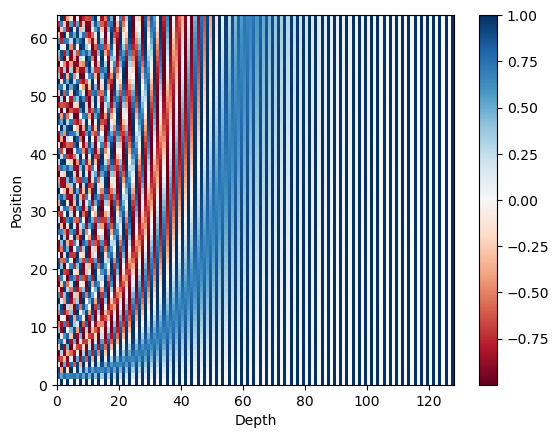

In [5]:
import matplotlib.pyplot as plt

n_seq = 64 ##시퀸스 의 수
pos_encoding = get_sinusoid_encoding_table(n_seq, d_hidn)

print (pos_encoding.shape) # 크기 출력
plt.pcolormesh(pos_encoding, cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, d_hidn))
plt.ylabel('Position')
plt.colorbar()
plt.show()

포지션 엔코딩이란 입력된 벡터의 포지션값에 대해 임베딩값을 구해서 더해주는 것.

In [6]:
pos_encoding = torch.FloatTensor(pos_encoding)
nn_pos = nn.Embedding.from_pretrained(pos_encoding, freeze=True)

positions = torch.arange(inputs.size(1), device=inputs.device, dtype=inputs.dtype).expand(inputs.size(0), inputs.size(1)).contiguous() + 1
pos_mask = inputs.eq(0)

positions.masked_fill_(pos_mask, 0)  ## 실제 패딩되어있는 값은 0으로 처리
pos_embs = nn_pos(positions) # position embedding

print(inputs) ## 입력값이자 vocab id
print(positions) ##인덱싱으로 나타낸 포지션값
print(pos_embs.size())

tensor([[3395, 3996,  185, 4330, 4142, 3984,    0,    0],
        [ 205, 3999,   57, 4234, 3990, 4078, 4142, 3984]])
tensor([[1, 2, 3, 4, 5, 6, 0, 0],
        [1, 2, 3, 4, 5, 6, 7, 8]])
torch.Size([2, 8, 128])


In [7]:
input_sums = input_embs + pos_embs

### 3. Scaled Dot Product Attention

임베딩 벡터를 QKV 벡터로 만들어서 attention score를 구할려고 합니다.  
attention을 구현중 QKV가 입력 시퀸스 내에서 서로만 볼 경우 self attention    
디코더가 인코더의 KV를 볼 경우 cross attention이다.

In [8]:
Q = input_sums
K = input_sums
V = input_sums
attn_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))
print(attn_mask.size())
print(attn_mask[0])

torch.Size([2, 8, 8])
tensor([[False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False,  True,  True]])


In [9]:
scores = torch.matmul(Q, K.transpose(-1, -2))
print(scores.size())
print(scores[0])

torch.Size([2, 8, 8])
tensor([[179.7611,  93.0155,  67.5941,  84.2427,  37.3828,  68.1117,  48.2376,
          48.2376],
        [ 93.0155, 277.1837, 116.2479, 116.8003,  77.1717,  92.9677,  75.5725,
          75.5725],
        [ 67.5941, 116.2479, 204.0943,  84.1552,  85.6477,  62.4267,  56.1157,
          56.1157],
        [ 84.2427, 116.8003,  84.1552, 238.8271,  78.1973,  81.6884,  40.2212,
          40.2212],
        [ 37.3828,  77.1717,  85.6477,  78.1973, 202.7393,  84.3134,  46.6399,
          46.6399],
        [ 68.1117,  92.9677,  62.4267,  81.6884,  84.3134, 216.9914,  45.6806,
          45.6806],
        [ 48.2376,  75.5725,  56.1157,  40.2212,  46.6399,  45.6806, 199.8838,
         199.8838],
        [ 48.2376,  75.5725,  56.1157,  40.2212,  46.6399,  45.6806, 199.8838,
         199.8838]], grad_fn=<SelectBackward0>)


Q K 값이 행렬곱을 할 수 있도록 transpose 하였다.

In [10]:
d_head = 64
scores = scores.mul_(1/d_head**0.5)  ### 스케일링을 위해 헤드의 차원수의 루트값을 나눠준다.
print(scores.size())
print(scores[0])

torch.Size([2, 8, 8])
tensor([[22.4701, 11.6269,  8.4493, 10.5303,  4.6729,  8.5140,  6.0297,  6.0297],
        [11.6269, 34.6480, 14.5310, 14.6000,  9.6465, 11.6210,  9.4466,  9.4466],
        [ 8.4493, 14.5310, 25.5118, 10.5194, 10.7060,  7.8033,  7.0145,  7.0145],
        [10.5303, 14.6000, 10.5194, 29.8534,  9.7747, 10.2111,  5.0276,  5.0276],
        [ 4.6729,  9.6465, 10.7060,  9.7747, 25.3424, 10.5392,  5.8300,  5.8300],
        [ 8.5140, 11.6210,  7.8033, 10.2111, 10.5392, 27.1239,  5.7101,  5.7101],
        [ 6.0297,  9.4466,  7.0145,  5.0276,  5.8300,  5.7101, 24.9855, 24.9855],
        [ 6.0297,  9.4466,  7.0145,  5.0276,  5.8300,  5.7101, 24.9855, 24.9855]],
       grad_fn=<SelectBackward0>)


In [11]:
scores.masked_fill_(attn_mask, -1e9) ### 마스크를 아주 작은 음수값으로 
print(scores.size())
print(scores[0])

torch.Size([2, 8, 8])
tensor([[ 2.2470e+01,  1.1627e+01,  8.4493e+00,  1.0530e+01,  4.6729e+00,
          8.5140e+00, -1.0000e+09, -1.0000e+09],
        [ 1.1627e+01,  3.4648e+01,  1.4531e+01,  1.4600e+01,  9.6465e+00,
          1.1621e+01, -1.0000e+09, -1.0000e+09],
        [ 8.4493e+00,  1.4531e+01,  2.5512e+01,  1.0519e+01,  1.0706e+01,
          7.8033e+00, -1.0000e+09, -1.0000e+09],
        [ 1.0530e+01,  1.4600e+01,  1.0519e+01,  2.9853e+01,  9.7747e+00,
          1.0211e+01, -1.0000e+09, -1.0000e+09],
        [ 4.6729e+00,  9.6465e+00,  1.0706e+01,  9.7747e+00,  2.5342e+01,
          1.0539e+01, -1.0000e+09, -1.0000e+09],
        [ 8.5140e+00,  1.1621e+01,  7.8033e+00,  1.0211e+01,  1.0539e+01,
          2.7124e+01, -1.0000e+09, -1.0000e+09],
        [ 6.0297e+00,  9.4466e+00,  7.0145e+00,  5.0276e+00,  5.8300e+00,
          5.7101e+00, -1.0000e+09, -1.0000e+09],
        [ 6.0297e+00,  9.4466e+00,  7.0145e+00,  5.0276e+00,  5.8300e+00,
          5.7101e+00, -1.0000e+09, -1.0000e

In [12]:
attn_prob = nn.Softmax(dim=-1)(scores)   ### 소프트맥스 함수를 씨서 패딩된 값은 0 가중치는 확률값
print(attn_prob.size())
print(attn_prob[0])

torch.Size([2, 8, 8])
tensor([[9.9997e-01, 1.9537e-05, 8.1432e-07, 6.5252e-06, 1.8652e-08, 8.6875e-07,
         0.0000e+00, 0.0000e+00],
        [1.0048e-10, 1.0000e+00, 1.8336e-09, 1.9647e-09, 1.3867e-11, 9.9885e-11,
         0.0000e+00, 0.0000e+00],
        [3.8889e-08, 1.7025e-05, 9.9998e-01, 3.0823e-07, 3.7145e-07, 2.0385e-08,
         0.0000e+00, 0.0000e+00],
        [4.0560e-09, 2.3744e-07, 4.0119e-09, 1.0000e+00, 1.9051e-09, 2.9474e-09,
         0.0000e+00, 0.0000e+00],
        [1.0552e-09, 1.5252e-07, 4.4002e-07, 1.7338e-07, 1.0000e+00, 3.7242e-07,
         0.0000e+00, 0.0000e+00],
        [8.2755e-09, 1.8499e-07, 4.0661e-09, 4.5168e-08, 6.2710e-08, 1.0000e+00,
         0.0000e+00, 0.0000e+00],
        [2.7729e-02, 8.4500e-01, 7.4235e-02, 1.0180e-02, 2.2709e-02, 2.0143e-02,
         0.0000e+00, 0.0000e+00],
        [2.7729e-02, 8.4500e-01, 7.4235e-02, 1.0180e-02, 2.2709e-02, 2.0143e-02,
         0.0000e+00, 0.0000e+00]], grad_fn=<SelectBackward0>)


In [13]:
context = torch.matmul(attn_prob, V)  ### attention score의 V벡터를 가중합하여 문맥 vector를 계산
print(context.size())

torch.Size([2, 8, 128])


모듈로 만들기

In [14]:
""" scale dot product attention """
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_head):
        super().__init__()
        self.scale = 1 / (d_head ** 0.5) ### 스케일링
    
    def forward(self, Q, K, V, attn_mask):
        # (bs, n_head, n_q_seq, n_k_seq)
        scores = torch.matmul(Q, K.transpose(-1, -2)).mul_(self.scale) ### QK 내적에 스케일링한 attention 점수
        scores.masked_fill_(attn_mask, -1e9)   ### 패딩 마스크
        # (bs, n_head, n_q_seq, n_k_seq)
        attn_prob = nn.Softmax(dim=-1)(scores)  ### 소프트맥스 함수
        # (bs, n_head, n_q_seq, d_v)
        context = torch.matmul(attn_prob, V)  ### V벡터 가중합
        # (bs, n_head, n_q_seq, d_v), (bs, n_head, n_q_seq, n_v_seq)
        return context, attn_prob

### 4. 멀티 헤드 어텐션.

싱글 헤드 어텐션이 헤드수 만큼 어텐션 점수를 구하고 V벡터를 가중합 한 결과들을 concat

In [15]:
# input_sums: token embedding + positional embedding
# shape: [batch_size, n_seq, d_hidn]
Q = input_sums
K = input_sums
V = input_sums
attn_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))

batch_size = Q.size(0)
n_head = 2

논문에서는 8개지만 2개만 구현해 봅니다.

In [16]:
### Q를 여러개의 head로 나누는 과정
W_Q = nn.Linear(d_hidn, n_head * d_head)
W_K = nn.Linear(d_hidn, n_head * d_head)
W_V = nn.Linear(d_hidn, n_head * d_head)  ### 입력 토큰 벡터를 Q, K, V 벡터로 만들기 위한 가중치 행렬 생성

# (bs, n_seq, n_head * d_head)
q_s = W_Q(Q)  ### Q벡터가 가중치행렬에 곱해짐
print(q_s.size())
# (bs, n_seq, n_head, d_head)
q_s = q_s.view(batch_size, -1, n_head, d_head)  ### 헤드수 만큼 Q 벡터가 나눠짐
print(q_s.size())
# (bs, n_head, n_seq, d_head)
q_s = q_s.transpose(1,2)  ## 전치해서 계산하기 편한 shape로 바꿈
print(q_s.size())

torch.Size([2, 8, 128])
torch.Size([2, 8, 2, 64])
torch.Size([2, 2, 8, 64])


In [17]:
# (bs, n_head, n_seq, d_head)
q_s = W_Q(Q).view(batch_size, -1, n_head, d_head).transpose(1,2)
# (bs, n_head, n_seq, d_head)
k_s = W_K(K).view(batch_size, -1, n_head, d_head).transpose(1,2)
# (bs, n_head, n_seq, d_head)
v_s = W_V(V).view(batch_size, -1, n_head, d_head).transpose(1,2)
print(q_s.size(), k_s.size(), v_s.size())

torch.Size([2, 2, 8, 64]) torch.Size([2, 2, 8, 64]) torch.Size([2, 2, 8, 64])


Q, K, V 모두 헤드 수로 나누었다.

In [18]:
print(attn_mask.size())
attn_mask = attn_mask.unsqueeze(1).repeat(1, n_head, 1, 1)
print(attn_mask.size())

torch.Size([2, 8, 8])
torch.Size([2, 2, 8, 8])


In [19]:
scaled_dot_attn = ScaledDotProductAttention(d_head)
context, attn_prob = scaled_dot_attn(q_s, k_s, v_s, attn_mask)
print(context.size())
print(attn_prob.size())

torch.Size([2, 2, 8, 64])
torch.Size([2, 2, 8, 8])


In [20]:
###헤드 수만큼 attention 계산한 결과를 차원수와 텐서 형태를 바꿔서 다시 합치는 과정
context = context.transpose(1, 2).contiguous().view(batch_size, -1, n_head * d_head)
print(context.size())

torch.Size([2, 8, 128])


transpose(1,2)를 하여 n_seq와 n_head 위치를 바꾸고 contiguous로 메모리상으로도 연속적인 텐서로 만들어 줍니다.  
view(batch_size, -1, n_head * d_head)를 통해 [batch_size, n_seq, n_head * d_head] 형태로 합침  
형태로는 결합되어 있지만 하나의 표현으로 합쳐지진 않은 상태.

In [21]:
linear = nn.Linear(n_head * d_head, d_hidn)  ### context를 선현변환하여 output으로 만든다.
# (bs, n_seq, d_hidn)
output = linear(context)
print(output.size())

torch.Size([2, 8, 128])


head별 결과가 나란히 붙어 있는 상태에서 한 표현에 섞어서 output projection으로 통합

In [22]:
""" multi head attention """
class MultiHeadAttention(nn.Module):
    def __init__(self, d_hidn, n_head, d_head):
        super().__init__()
        self.d_hidn = d_hidn
        self.n_head = n_head
        self.d_head = d_head

        self.W_Q = nn.Linear(d_hidn, n_head * d_head)
        self.W_K = nn.Linear(d_hidn, n_head * d_head)
        self.W_V = nn.Linear(d_hidn, n_head * d_head)
        self.scaled_dot_attn = ScaledDotProductAttention(d_head)
        self.linear = nn.Linear(n_head * d_head, d_hidn)
    
    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.size(0)
        # (bs, n_head, n_q_seq, d_head)
        q_s = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1,2)
        # (bs, n_head, n_k_seq, d_head)
        k_s = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1,2)
        # (bs, n_head, n_v_seq, d_head)
        v_s = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1,2)

        # (bs, n_head, n_q_seq, n_k_seq)
        attn_mask = attn_mask.unsqueeze(1).repeat(1, self.n_head, 1, 1)

        # (bs, n_head, n_q_seq, d_head), (bs, n_head, n_q_seq, n_k_seq)
        context, attn_prob = self.scaled_dot_attn(q_s, k_s, v_s, attn_mask)
        # (bs, n_head, n_q_seq, h_head * d_head)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.n_head * self.d_head)
        # (bs, n_head, n_q_seq, e_embd)
        output = self.linear(context)
        # (bs, n_q_seq, d_hidn), (bs, n_head, n_q_seq, n_k_seq)
        return output, attn_prob

### 5. Masked Multi-Head Attention

디코더 마스크 함수 생성 (어퍼삼각행렬)

In [23]:
""" attention decoder mask """
def get_attn_decoder_mask(seq):
    subsequent_mask = torch.ones_like(seq).unsqueeze(-1).expand(seq.size(0), seq.size(1), seq.size(1))
    subsequent_mask = subsequent_mask.triu(diagonal=1) # upper triangular part of a matrix(2-D)
    return subsequent_mask


Q = input_sums
K = input_sums
V = input_sums

attn_pad_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))
print(attn_pad_mask[1])
attn_dec_mask = get_attn_decoder_mask(inputs)
print(attn_dec_mask[1])
attn_mask = torch.gt((attn_pad_mask + attn_dec_mask), 0)
print(attn_mask[1])

batch_size = Q.size(0)
n_head = 2

tensor([[False, False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False, False]])
tensor([[0, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[False,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True],


In [24]:
attention = MultiHeadAttention(d_hidn, n_head, d_head)
output, attn_prob = attention(Q, K, V, attn_mask)
print(output.size(), attn_prob.size())

torch.Size([2, 8, 128]) torch.Size([2, 2, 8, 8])


### 6. FeedForward

피드포워드레이어는 선형변환함수를 2번 활성화 함수를 1번 지나가게 된다.

In [25]:
conv1 = nn.Conv1d(in_channels=d_hidn, out_channels = d_hidn *4, kernel_size =1)
# (bs, d_hidn * 4, n_seq)
ff_1 = conv1(output.transpose(1, 2))
print(ff_1.size())

torch.Size([2, 512, 8])


입력에 비해 4배 커졌다.

Activation (relu or gelu) 비선형성을 추가하기 위한 영역

In [26]:
import torch.nn.functional as F
# active = F.relu
active = F.gelu
ff_2 = active(ff_1)

Relu보다 Gelu가 음수값 처리에 더 부드러워서 많이 사용하게 되었다.

In [27]:
conv2 = nn.Conv1d(in_channels=d_hidn * 4, out_channels=d_hidn, kernel_size=1)
ff_3 = conv2(ff_2).transpose(1, 2)
print(ff_3.size())

torch.Size([2, 8, 128])


입력 차원과 같은 수로 돌아옴

In [28]:
""" feed forward """
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_hidn):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=self.config.d_hidn, out_channels=self.config.d_hidn * 4, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=self.config.d_hidn * 4, out_channels=self.config.d_hidn, kernel_size=1)
        self.active = F.gelu

    def forward(self, inputs):
        # (bs, d_ff, n_seq)
        output = self.active(self.conv1(inputs.transpose(1, 2)))
        # (bs, n_seq, d_hidn)
        output = self.conv2(output).transpose(1, 2)
        # (bs, n_seq, d_hidn)
        return output

congfig 설정값 지정

In [29]:
""" configuration json을 읽어들이는 class """
class Config(dict): 
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

In [30]:
config = Config({
    "n_enc_vocab": len(vocab),
    "n_dec_vocab": len(vocab),
    "n_enc_seq": 256,
    "n_dec_seq": 256,
    "n_layer": 6,
    "d_hidn": 256,
    "i_pad": 0,
    "d_ff": 1024,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "layer_norm_epsilon": 1e-12
})
print(config)

{'n_enc_vocab': 8007, 'n_dec_vocab': 8007, 'n_enc_seq': 256, 'n_dec_seq': 256, 'n_layer': 6, 'd_hidn': 256, 'i_pad': 0, 'd_ff': 1024, 'n_head': 4, 'd_head': 64, 'dropout': 0.1, 'layer_norm_epsilon': 1e-12}


### 7. Encoder Layer

인코더 레이어는 셀프 어텐션 레이어와 피드포워드넷 레이어로 구성되었습니다.


In [31]:
""" encoder layer """
class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.self_attn = MultiHeadAttention(self.config)
        self.layer_norm1 = nn.LayerNorm(self.config.d_hidn, eps=self.config.layer_norm_epsilon)
        self.pos_ffn = PoswiseFeedForwardNet(self.config)
        self.layer_norm2 = nn.LayerNorm(self.config.d_hidn, eps=self.config.layer_norm_epsilon)
    
    def forward(self, inputs, attn_mask):
        # (bs, n_enc_seq, d_hidn), (bs, n_head, n_enc_seq, n_enc_seq)
        att_outputs, attn_prob = self.self_attn(inputs, inputs, inputs, attn_mask)
        att_outputs = self.layer_norm1(inputs + att_outputs)
        # (bs, n_enc_seq, d_hidn)
        ffn_outputs = self.pos_ffn(att_outputs)
        ffn_outputs = self.layer_norm2(ffn_outputs + att_outputs)
        # (bs, n_enc_seq, d_hidn), (bs, n_head, n_enc_seq, n_enc_seq)
        return ffn_outputs, attn_prob

멀티헤드 어텐션 모듈은 입력 임베딩 벡터를 받아 Q, K, V를 만들고,
각 토큰이 다른 토큰들과 얼마나 관련 있는지 계산하여 attention output을 생성한다.

이 attention output은 원래 입력과 잔차 연결(residual connection)로 더해지고,
Layer Normalization을 거쳐 안정화된다.

그 다음 Position-wise Feed Forward Network가 이 결과를 받아
선형변환 → 활성화 함수 → 선형변환 과정을 수행한다.
이 과정에서 내부 차원은 확장되었다가 다시 d_hidn 차원으로 돌아온다.

Feed Forward Network의 출력도 다시 이전 입력과 잔차 연결로 더해지고,
Layer Normalization을 거친다.

이러한 Encoder Layer가 설정된 층수만큼 반복되면서,
각 토큰의 표현은 문장 전체의 문맥 정보를 반영하도록 점점 업데이트된다.
최종적으로 마지막 Encoder Layer의 출력이 encoder output이 된다. 

In [32]:
""" encoder """
class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.enc_emb = nn.Embedding(self.config.n_enc_vocab, self.config.d_hidn)
        sinusoid_table = torch.FloatTensor(get_sinusoid_encoding_table(self.config.n_enc_seq + 1, self.config.d_hidn))
        self.pos_emb = nn.Embedding.from_pretrained(sinusoid_table, freeze=True)

        self.layers = nn.ModuleList([EncoderLayer(self.config) for _ in range(self.config.n_layer)])
    
    def forward(self, inputs):
        positions = torch.arange(inputs.size(1), device=inputs.device, dtype=inputs.dtype).expand(inputs.size(0), inputs.size(1)).contiguous() + 1
        pos_mask = inputs.eq(self.config.i_pad)
        positions.masked_fill_(pos_mask, 0)

        # (bs, n_enc_seq, d_hidn)
        outputs = self.enc_emb(inputs) + self.pos_emb(positions)

        # (bs, n_enc_seq, n_enc_seq)
        attn_mask = get_attn_pad_mask(inputs, inputs, self.config.i_pad)

        attn_probs = []
        for layer in self.layers:
            # (bs, n_enc_seq, d_hidn), (bs, n_head, n_enc_seq, n_enc_seq)
            outputs, attn_prob = layer(outputs, attn_mask)
            attn_probs.append(attn_prob)
        # (bs, n_enc_seq, d_hidn), [(bs, n_head, n_enc_seq, n_enc_seq)]
        return outputs, attn_probs

디코더 레이어는 멀티헤드 마스크드 셀프 어텐션 모듈과 디코더 인코더 어텐션 모듈, 피드포워드레이어로 구성된다.

In [33]:
""" decoder layer """
class DecoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.self_attn = MultiHeadAttention(self.config)
        self.layer_norm1 = nn.LayerNorm(self.config.d_hidn, eps=self.config.layer_norm_epsilon)
        self.dec_enc_attn = MultiHeadAttention(self.config)
        self.layer_norm2 = nn.LayerNorm(self.config.d_hidn, eps=self.config.layer_norm_epsilon)
        self.pos_ffn = PoswiseFeedForwardNet(self.config)
        self.layer_norm3 = nn.LayerNorm(self.config.d_hidn, eps=self.config.layer_norm_epsilon)
    
    def forward(self, dec_inputs, enc_outputs, self_attn_mask, dec_enc_attn_mask):
        # (bs, n_dec_seq, d_hidn), (bs, n_head, n_dec_seq, n_dec_seq)
        self_att_outputs, self_attn_prob = self.self_attn(dec_inputs, dec_inputs, dec_inputs, self_attn_mask)
        self_att_outputs = self.layer_norm1(dec_inputs + self_att_outputs)
        # (bs, n_dec_seq, d_hidn), (bs, n_head, n_dec_seq, n_enc_seq)
        dec_enc_att_outputs, dec_enc_attn_prob = self.dec_enc_attn(self_att_outputs, enc_outputs, enc_outputs, dec_enc_attn_mask)
        dec_enc_att_outputs = self.layer_norm2(self_att_outputs + dec_enc_att_outputs)
        # (bs, n_dec_seq, d_hidn)
        ffn_outputs = self.pos_ffn(dec_enc_att_outputs)
        ffn_outputs = self.layer_norm3(dec_enc_att_outputs + ffn_outputs)
        # (bs, n_dec_seq, d_hidn), (bs, n_head, n_dec_seq, n_dec_seq), (bs, n_head, n_dec_seq, n_enc_seq)
        return ffn_outputs, self_attn_prob, dec_enc_attn_prob

코더의 Self-Attention에는 디코더 입력이 Q, K, V로 사용된다.
이때 미래 토큰을 보지 않도록 mask가 적용된다.
Self-Attention 출력은 입력과 잔차 연결을 한 뒤 Layer Normalization을 수행한다.

이후 Encoder-Decoder Attention을 수행한다.
Q는 디코더 Self-Attention의 결과이고, K와 V는 인코더 출력이다.
이를 통해 디코더는 인코더가 만든 원문 표현 중 필요한 정보를 참조한다.
이 결과도 잔차 연결과 Layer Normalization을 거친다.

마지막으로 FFN을 통과하여 각 토큰 표현을 변환하고,
FFN 출력 역시 잔차 연결과 Layer Normalization을 거쳐
디코더 레이어의 최종 출력이 된다.

In [34]:
""" decoder """
class Decoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        ### 임베딩 벡터 생성과 위치정보를 위한 sinusoid table
        self.dec_emb = nn.Embedding(self.config.n_dec_vocab, self.config.d_hidn)
        sinusoid_table = torch.FloatTensor(get_sinusoid_encoding_table(self.config.n_dec_seq + 1, self.config.d_hidn))
        self.pos_emb = nn.Embedding.from_pretrained(sinusoid_table, freeze=True)

        self.layers = nn.ModuleList([DecoderLayer(self.config) for _ in range(self.config.n_layer)])
    
    def forward(self, dec_inputs, enc_inputs, enc_outputs):
        positions = torch.arange(dec_inputs.size(1), device=dec_inputs.device, dtype=dec_inputs.dtype).expand(dec_inputs.size(0), dec_inputs.size(1)).contiguous() + 1
        pos_mask = dec_inputs.eq(self.config.i_pad)
        positions.masked_fill_(pos_mask, 0)
    
        # (bs, n_dec_seq, d_hidn)
        dec_outputs = self.dec_emb(dec_inputs) + self.pos_emb(positions)
        ### 디코더 마스크와 패딩 마스크
        # (bs, n_dec_seq, n_dec_seq)
        dec_attn_pad_mask = get_attn_pad_mask(dec_inputs, dec_inputs, self.config.i_pad)
        # (bs, n_dec_seq, n_dec_seq)
        dec_attn_decoder_mask = get_attn_decoder_mask(dec_inputs)
        # (bs, n_dec_seq, n_dec_seq)
        dec_self_attn_mask = torch.gt((dec_attn_pad_mask + dec_attn_decoder_mask), 0)
        # (bs, n_dec_seq, n_enc_seq)
        dec_enc_attn_mask = get_attn_pad_mask(dec_inputs, enc_inputs, self.config.i_pad)

        self_attn_probs, dec_enc_attn_probs = [], []
        for layer in self.layers:
            # (bs, n_dec_seq, d_hidn), (bs, n_dec_seq, n_dec_seq), (bs, n_dec_seq, n_enc_seq)
            dec_outputs, self_attn_prob, dec_enc_attn_prob = layer(dec_outputs, enc_outputs, dec_self_attn_mask, dec_enc_attn_mask)
            self_attn_probs.append(self_attn_prob)
            dec_enc_attn_probs.append(dec_enc_attn_prob)
        # (bs, n_dec_seq, d_hidn), [(bs, n_dec_seq, n_dec_seq)], [(bs, n_dec_seq, n_enc_seq)]S
        return dec_outputs, self_attn_probs, dec_enc_attn_probs

### 8. transfomer

In [35]:
""" transformer """
class Transformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.encoder = Encoder(self.config)
        self.decoder = Decoder(self.config)
    
    def forward(self, enc_inputs, dec_inputs):
        # (bs, n_enc_seq, d_hidn), [(bs, n_head, n_enc_seq, n_enc_seq)]
        enc_outputs, enc_self_attn_probs = self.encoder(enc_inputs)
        # (bs, n_seq, d_hidn), [(bs, n_head, n_dec_seq, n_dec_seq)], [(bs, n_head, n_dec_seq, n_enc_seq)]
        dec_outputs, dec_self_attn_probs, dec_enc_attn_probs = self.decoder(dec_inputs, enc_inputs, enc_outputs)
        # (bs, n_dec_seq, n_dec_vocab), [(bs, n_head, n_enc_seq, n_enc_seq)], [(bs, n_head, n_dec_seq, n_dec_seq)], [(bs, n_head, n_dec_seq, n_enc_seq)]
        return dec_outputs, enc_self_attn_probs, dec_self_attn_probs, dec_enc_attn_probs

enc_outputs : Encoder의 최종 출력  
enc_self_attn_probs : Encoder Self-Attention의 attention probability입니다.  
dec_inputs  : target 문장의 입력    
enc_inputs  : source 문장의 padding mask를 만들기 위한 입력  
enc_outputs : encoder가 만든 source 문장 표현

In [36]:
### 최종적으로 디코더가 생성한 타켓 벡터를 logits 최종점수로 바꿔서 vocab에 맵핑하여 타켓 단어로 바꿔줘야 한다.
""" naver movie classfication """
class MovieClassification(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = Transformer(self.config)
        self.projection = nn.Linear(self.config.d_hidn, self.config.n_output, bias=False)
    
    def forward(self, enc_inputs, dec_inputs):
        # (bs, n_dec_seq, d_hidn), [(bs, n_head, n_enc_seq, n_enc_seq)], [(bs, n_head, n_dec_seq, n_dec_seq)], [(bs, n_head, n_dec_seq, n_enc_seq)]
        dec_outputs, enc_self_attn_probs, dec_self_attn_probs, dec_enc_attn_probs = self.transformer(enc_inputs, dec_inputs)
        # (bs, d_hidn) ### 디코더 아웃풋을 받아와서
        dec_outputs, _ = torch.max(dec_outputs, dim=1)  ### 확률값으로 나타냄
        # (bs, n_output)
        logits = self.projection(dec_outputs)  ### 선형변환으로 단어화
        # (bs, n_output), [(bs, n_head, n_enc_seq, n_enc_seq)], [(bs, n_head, n_dec_seq, n_dec_seq)], [(bs, n_head, n_dec_seq, n_enc_seq)]
        return logits, enc_self_attn_probs, dec_self_attn_probs, dec_enc_attn_probs

노드내용을 바탕으로 번역기 기능으로 학습하고 실제로 번역 해보기.

In [37]:
!sudo apt update
!sudo apt-get install -y fonts-nanum

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
131 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 131 not upgraded.


한글 폰트 설정

In [38]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


시드 고정

In [39]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


라이브러리 버젼 확인

In [40]:
import torch
import numpy
import matplotlib

print(torch.__version__)
print(numpy.__version__)
print(matplotlib.__version__)

2.7.1+cu118
2.2.6
3.10.3


gpu 사용

In [41]:
import os, re, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)

torch: 2.7.1+cu118 | device: cuda


In [42]:
HOME = os.getenv("HOME")
candidate_dirs = [
    os.path.join(HOME, "work/transformer/data"),
    "/content",
    ".",
]

DATA_DIR = None
for d in candidate_dirs:
    if os.path.exists(os.path.join(d, "korean-english-park.train.ko")):
        DATA_DIR = d
        break

if DATA_DIR is None:
    DATA_DIR = candidate_dirs[0]
    os.makedirs(DATA_DIR, exist_ok=True)
    url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/"
           "master/korean-english-news-v1/korean-english-park.train.tar.gz")
    os.system(f"wget -q {url} -P {DATA_DIR}")
    os.system(f"gzip -df {DATA_DIR}/korean-english-park.train.tar.gz")
    os.system(f"tar -xf {DATA_DIR}/korean-english-park.train.tar -C {DATA_DIR}")

KOR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")
print("DATA_DIR:", DATA_DIR)
print("kor:", os.path.exists(KOR_PATH), "eng:", os.path.exists(ENG_PATH))

DATA_DIR: .
kor: True eng: True


In [43]:
def preprocess_sentence(sentence: str) -> str:
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

def load_pairs(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        if key in seen:
            continue
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs

pairs = load_pairs(KOR_PATH, ENG_PATH)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print("예시:", pairs[0])

kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]

중복 제거 후 병렬쌍: 78,968
예시: ('개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?', 'much of personal computing is about can you top this ?')


In [44]:
import sentencepiece as spm

SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"
    with open(txt_path, "w") as f:
        for row in corpus:
            f.write(row + "\n")

    # FIX: 원본 코드는 공백 누락 + '--pad_id==%d' (등호 두 개) 로 학습이 깨짐.
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk

print("토크나이저 학습 중...")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
print("ko vocab:", ko_tokenizer.get_piece_size(),
      "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))

토크나이저 학습 중...


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=./ko_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ./ko_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_voca

ko vocab: 8000 en vocab: 8000
샘플 인코딩: ['<s>', '▁hel', 'lo', '▁world', '</s>']


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./en_corpus.txt --model_prefix=./en_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./en_corpus.txt
  input_format: 
  model_prefix: ./en_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_voca

In [45]:
MAX_LEN = 40

src_corpus, tgt_corpus = [], []
for k, e in zip(kor_corpus, eng_corpus):
    s = ko_tokenizer.encode_as_ids(k)
    t = en_tokenizer.encode_as_ids(e)  # bos/eos 포함
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"학습용 병렬쌍: {len(src_corpus):,}")
print("src 예시 len:", len(src_corpus[0]), "tgt 예시 len:", len(tgt_corpus[0]))

: freq=335 size=2060 all=41887 active=2375 piece=▁victims
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=328 size=2080 all=42035 active=2523 piece=▁voters
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=323 size=2100 all=42232 active=2720 piece=▁light
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=323 min_freq=131
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=319 size=2120 all=42345 active=2216 piece=▁results
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=315 size=2140 all=42490 active=2361 piece=▁movie
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=312 size=2160 all=42699 active=2570 piece=▁summit
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=307 size=2180 all=42824 active=2695 piece=▁tib
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=303 size=2200 all=42840 active=2711 piece=ays
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=303 min_freq=125
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=300 size=2220 all=43051 active=2329 piece=

학습용 병렬쌍: 58,876
src 예시 len: 16 tgt 예시 len: 15


In [46]:
def positional_encoding(pos_len, d_model):
    pe = np.zeros((pos_len, d_model), dtype=np.float32)
    position = np.arange(0, pos_len)[:, None]
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return torch.from_numpy(pe)  # [pos_len, d_model]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def _split(self, x):
        b, t, _ = x.shape
        return x.view(b, t, self.num_heads, self.depth).transpose(1, 2)

    def _combine(self, x):
        b, h, t, d = x.shape
        return x.transpose(1, 2).contiguous().view(b, t, h * d)

    def forward(self, Q, K, V, mask=None):
        # mask: bool, True 인 위치를 가린다. shape broadcast-able to (B, H, Tq, Tk).
        Q = self._split(self.W_q(Q))
        K = self._split(self.W_k(K))
        V = self._split(self.W_v(V))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, V)
        out = self._combine(out)
        return self.linear(out), attn


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.gelu(self.w_1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        h = self.norm_1(x)
        h, attn = self.self_attn(h, h, h, src_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        x = x + self.dropout(self.ffn(h))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        h = self.norm_1(x)
        h, self_attn = self.self_attn(h, h, h, tgt_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        # FIX: cross-attention 에는 인코더 패딩 마스크만 (causal X)
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)
        x = x + self.dropout(h)

        h = self.norm_3(x)
        x = x + self.dropout(self.ffn(h))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, src_mask):
        attns = []
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa); cross_attns.append(ca)
        return x, self_attns, cross_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)
        if shared:
            self.fc.weight = self.dec_emb.weight

        self._reset_parameters()

    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _embed(self, emb, x):
        # FIX: shared 여부와 무관하게 항상 sqrt(d_model) 스케일
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)
        return self.dropout(out)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        enc_in = self._embed(self.enc_emb, src)
        dec_in = self._embed(self.dec_emb, tgt)

        enc_out, enc_attns = self.encoder(enc_in, src_mask)
        dec_out, dec_attns, cross_attns = self.decoder(
            dec_in, enc_out, tgt_mask, memory_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns


print("모델 클래스 정의 완료")

모델 클래스 정의 완료


In [47]:
def padding_mask(seq):
    # True 이면 PAD. shape: [B, 1, 1, T]
    return (seq == 0).unsqueeze(1).unsqueeze(2)

def causal_mask(size, device):
    # True 이면 미래 위치. shape: [1, 1, size, size]
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return m.unsqueeze(0).unsqueeze(0)

def generate_masks(src, tgt):
    src_pad = padding_mask(src)                                # [B,1,1,Ts]
    tgt_pad = padding_mask(tgt)                                # [B,1,1,Tt]
    tgt_causal = causal_mask(tgt.size(1), tgt.device)          # [1,1,Tt,Tt]
    tgt_mask = tgt_pad | tgt_causal                            # broadcast → [B,1,Tt,Tt]
    memory_mask = src_pad                                      # cross-attn 은 enc padding 만
    return src_pad, tgt_mask, memory_mask

In [48]:
N_LAYERS = 4
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 1024
DROPOUT  = 0.1
POS_LEN  = MAX_LEN + 2
BATCH_SIZE = 128
EPOCHS = 20
WARMUP_STEPS = 4000
LABEL_SMOOTH = 0.1

model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN, dropout=DROPOUT, shared=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"파라미터 수: {n_params/1e6:.2f}M")

파라미터 수: 11.47M


In [49]:
def noam_lr(d_model, warmup):
    def lr(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    """Label smoothing + ignore PAD."""
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing

    def forward(self, logits, target):
        # logits: [B, T, V]; target: [B, T]
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            true_dist[:, :, self.pad_id] = 0
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask
        loss = -(true_dist * logp).sum(dim=-1)
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)
print("optimizer / scheduler / loss 준비 완료")

optimizer / scheduler / loss 준비 완료


In [50]:
from torch.nn.utils.rnn import pad_sequence

train_idx = list(range(len(src_corpus)))

def make_batch(indices):
    src = pad_sequence([src_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    tgt_in  = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)
    # NOTE: src_mask, memory_mask 는 본질적으로 같은 인코더 패딩 마스크지만
    # encoder self-attn vs cross-attn 에 같이 쓰입니다.

    optimizer.zero_grad()
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)
    loss = criterion(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    return loss.item()

In [51]:
print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_idx)
    total, n = 0.0, 0
    for s in range(0, len(train_idx), BATCH_SIZE):
        batch = train_idx[s : s + BATCH_SIZE]
        if not batch:
            continue
        src, tgt = make_batch(batch)
        loss = train_step(src, tgt)
        total += loss; n += 1
    print(f"Epoch {epoch:2d} | avg loss {total/max(1,n):.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"elapsed {time.time()-t0:.1f}s")

학습 시작: 20 epochs, batch=128, 데이터 58,876 문장
Epoch  1 | avg loss 7.4406 | lr 1.14e-04 | elapsed 63.9s
Epoch  2 | avg loss 6.4932 | lr 2.27e-04 | elapsed 123.2s
Epoch  3 | avg loss 5.9177 | lr 3.41e-04 | elapsed 182.4s
Epoch  4 | avg loss 5.5581 | lr 4.55e-04 | elapsed 241.4s
Epoch  5 | avg loss 5.2538 | lr 5.68e-04 | elapsed 300.6s
Epoch  6 | avg loss 5.0109 | lr 6.82e-04 | elapsed 359.9s
Epoch  7 | avg loss 4.8241 | lr 7.96e-04 | elapsed 419.0s
Epoch  8 | avg loss 4.6736 | lr 9.09e-04 | elapsed 478.2s
Epoch  9 | avg loss 4.5519 | lr 9.71e-04 | elapsed 537.5s
Epoch 10 | avg loss 4.4071 | lr 9.22e-04 | elapsed 596.8s
Epoch 11 | avg loss 4.2629 | lr 8.79e-04 | elapsed 656.0s
Epoch 12 | avg loss 4.1370 | lr 8.41e-04 | elapsed 715.3s
Epoch 13 | avg loss 4.0276 | lr 8.08e-04 | elapsed 774.5s
Epoch 14 | avg loss 3.9332 | lr 7.79e-04 | elapsed 833.7s
Epoch 15 | avg loss 3.8503 | lr 7.52e-04 | elapsed 892.9s
Epoch 16 | avg loss 3.7768 | lr 7.29e-04 | elapsed 952.2s
Epoch 17 | avg loss 3.7111 | l

In [52]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    model.eval()

    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None

    for _ in range(max_len):
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")   # <unk> 회피
        next_id = int(torch.argmax(next_logits).item())

        if next_id == EOS_ID:
            break
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )

    return en_tokenizer.decode_ids(generated), enc_attns, dec_attns, cross_attns


def translate(sentence):
    result, *_ = evaluate(sentence)
    return result

In [53]:
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")

 Korean → English Translations
 1. KO: 오바마는 대통령이다.
    EN: obama is the president .
----------------------------------------------------------------------
 2. KO: 시민들은 도시 속에 산다.
    EN: the city is in the town of sir .
----------------------------------------------------------------------
 3. KO: 커피는 필요 없다.
    EN: it s not just coffee .
----------------------------------------------------------------------
 4. KO: 일곱 명의 사망자가 발생했다.
    EN: seven people were killed in the disaster .
----------------------------------------------------------------------
 5. KO: 그는 어제 학교에 갔다.
    EN: he was later sworn in the school .
----------------------------------------------------------------------
 6. KO: 한국은 아름다운 나라이다.
    EN: south korea is beautiful in the beautiful country .
----------------------------------------------------------------------
 7. KO: 정부는 새로운 정책을 발표했다.
    EN: the government has set a new policy to set a new government .
--------------------------------------------------------